In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.read_csv('../../../data_capsule/ROUND_3/prices_round_3_day_0.csv', sep=';')
trades = pd.read_csv('../../../data_capsule/ROUND_3/trades_round_3_day_0.csv', sep=';')

prices.columns = prices.columns.str.strip()
trades.columns = trades.columns.str.strip()

products = sorted(prices['product'].unique())
print(products)

# Correct classification
underlying = 'VELVETFRUIT_EXTRACT'
vouchers = [p for p in products if p.startswith('VEV_')]

print("Underlying:", underlying)
print("Vouchers:", vouchers)

['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Underlying: VELVETFRUIT_EXTRACT
Vouchers: ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices.columns = prices.columns.str.lower().str.strip()
trades.columns = trades.columns.str.lower().str.strip()

# detect cols
product_col = [c for c in prices.columns if c in ['product','symbol','instrument']][0]
timestamp_col = [c for c in prices.columns if c in ['timestamp','time','ts']][0]

underlying = 'VELVETFRUIT_EXTRACT'
vouchers = [p for p in prices[product_col].unique() if str(p).startswith('VEV_')]

# mid
prices['mid'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2

# strike
prices['strike'] = prices[product_col].apply(
    lambda x: int(x.split('_')[1]) if str(x).startswith('VEV_') else np.nan
)

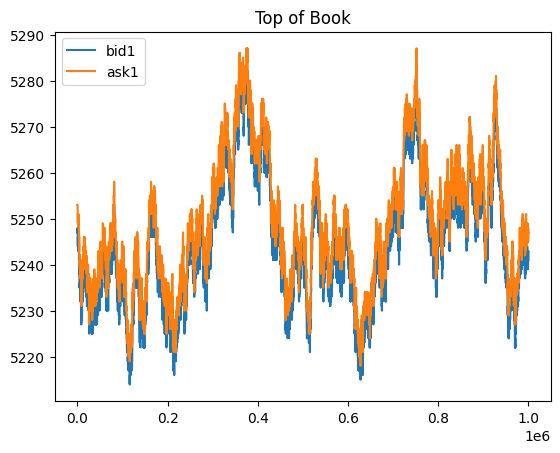

In [7]:
df = prices[prices[product_col] == underlying]

plt.figure()
plt.plot(df[timestamp_col], df['bid_price_1'], label='bid1')
plt.plot(df[timestamp_col], df['ask_price_1'], label='ask1')
plt.title("Top of Book")
plt.legend()
plt.show()

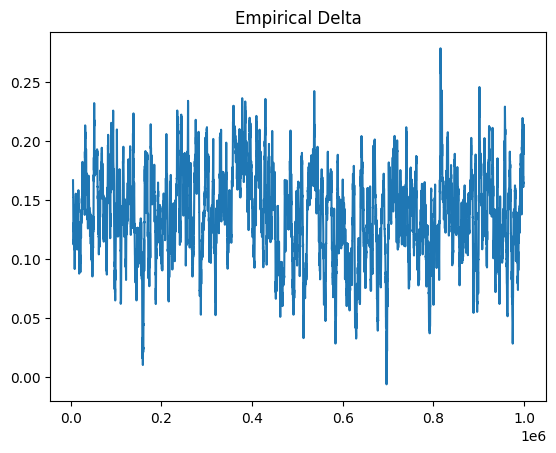

In [9]:
under = prices[prices[product_col] == underlying][[timestamp_col,'mid']]
opt = prices[prices[product_col] == vouchers[0]][[timestamp_col,'mid']]

merged = under.merge(opt, on=timestamp_col, suffixes=('_u','_o')).dropna()

# returns
merged['ret_u'] = merged['mid_u'].diff()
merged['ret_o'] = merged['mid_o'].diff()

# rolling regression = local delta
window = 50
merged['delta'] = (
    merged['ret_o'].rolling(window).cov(merged['ret_u']) /
    merged['ret_u'].rolling(window).var()
)

plt.plot(merged[timestamp_col], merged['delta'])
plt.title("Empirical Delta")
plt.show()

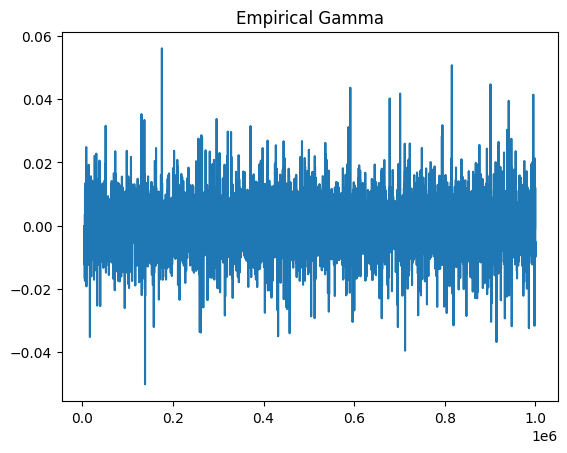

In [10]:
merged['gamma'] = merged['delta'].diff()

plt.plot(merged[timestamp_col], merged['gamma'])
plt.title("Empirical Gamma")
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices.columns = prices.columns.str.lower().str.strip()
trades.columns = trades.columns.str.lower().str.strip()

price_product_col = 'product' if 'product' in prices.columns else 'symbol'
trade_product_col = 'symbol'
time_col = 'timestamp'

underlying = 'VELVETFRUIT_EXTRACT'
vouchers = ['VEV_4000','VEV_4500','VEV_5000','VEV_5100','VEV_5200',
            'VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500']

prices['mid'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

prices['strike'] = prices[price_product_col].apply(
    lambda x: int(str(x).split('_')[1]) if str(x).startswith('VEV_') else np.nan
)

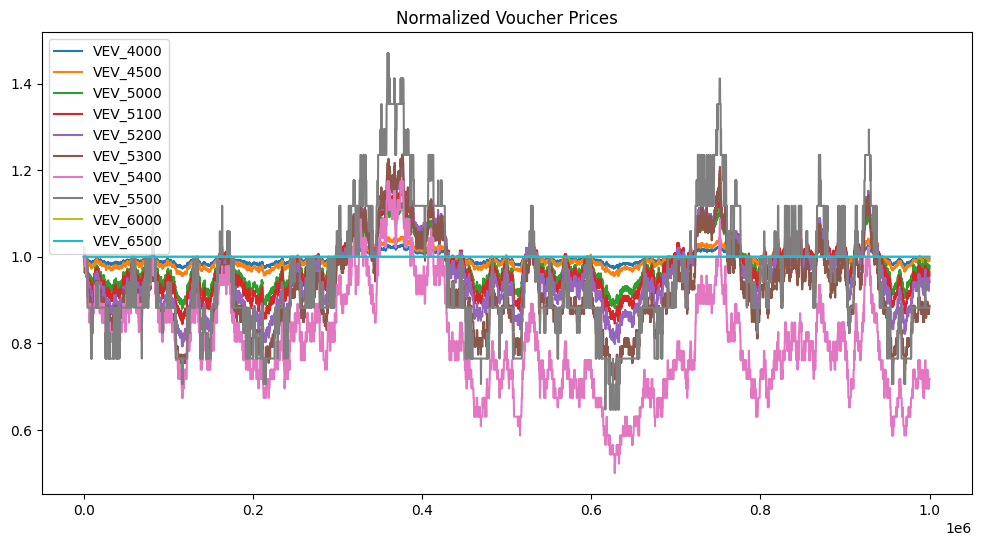

In [21]:
plt.figure(figsize=(12,6))

for v in vouchers:
    df = prices[prices[price_product_col] == v].copy()
    df['norm'] = df['mid'] / df['mid'].iloc[0]
    plt.plot(df[time_col], df['norm'], label=v)

plt.title("Normalized Voucher Prices")
plt.legend()
plt.show()

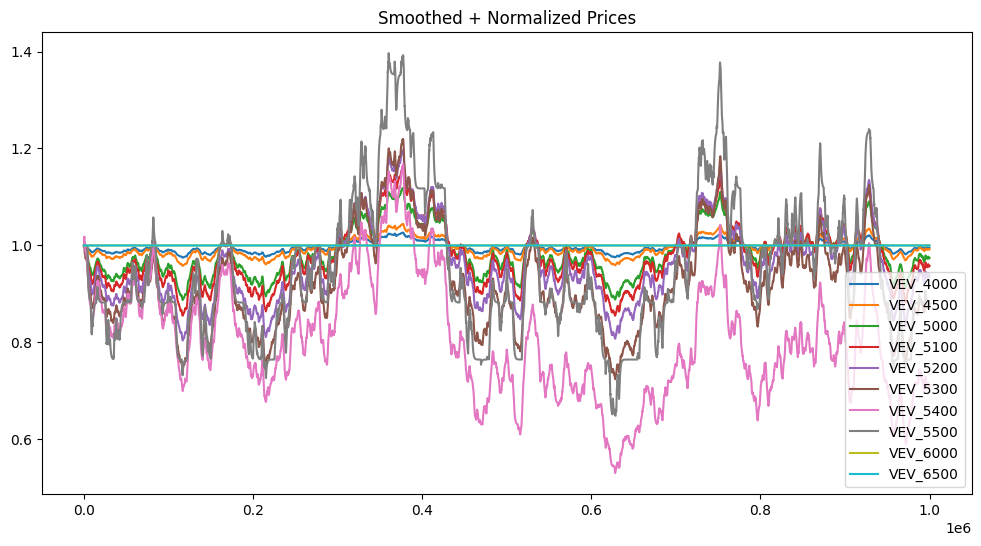

In [22]:
plt.figure(figsize=(12,6))

for v in vouchers:
    df = prices[prices[price_product_col] == v].copy()
    df['smooth'] = df['mid'].ewm(span=20).mean()
    df['norm'] = df['smooth'] / df['smooth'].iloc[0]
    plt.plot(df[time_col], df['norm'], label=v)

plt.title("Smoothed + Normalized Prices")
plt.legend()
plt.show()

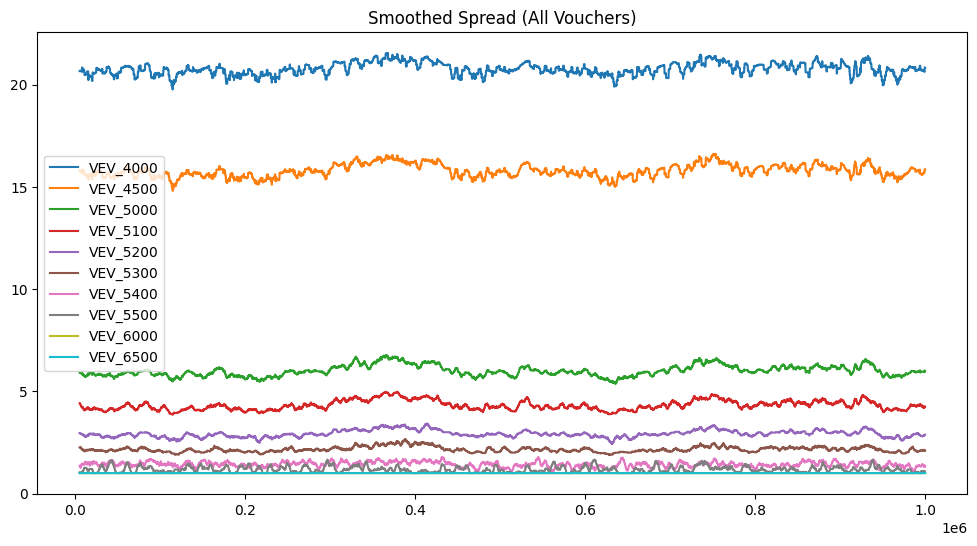

In [23]:
plt.figure(figsize=(12,6))

for v in vouchers:
    df = prices[prices[price_product_col] == v].copy()
    df['spread_smooth'] = df['spread'].rolling(50).mean()
    plt.plot(df[time_col], df['spread_smooth'], label=v)

plt.title("Smoothed Spread (All Vouchers)")
plt.legend()
plt.show()

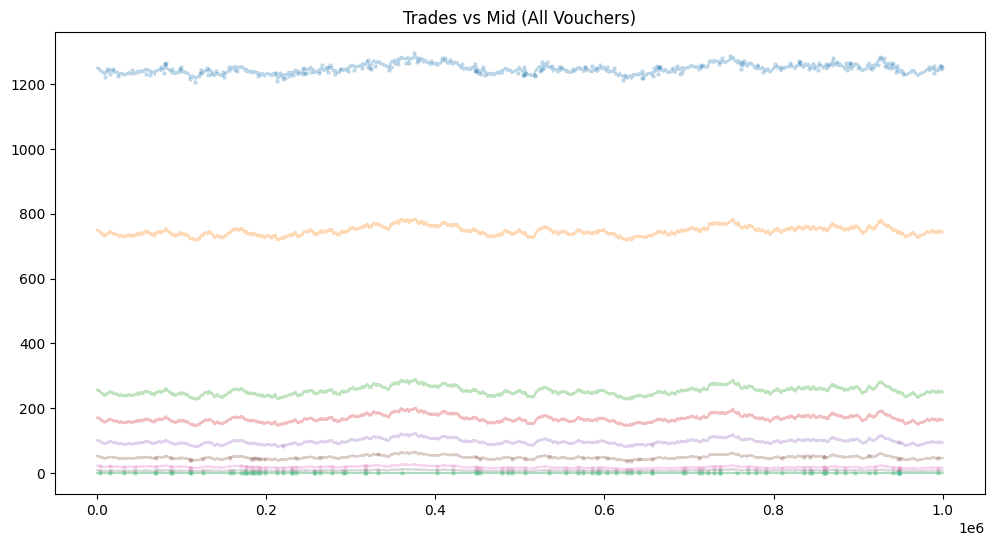

In [24]:
plt.figure(figsize=(12,6))

for v in vouchers:
    p = prices[prices[price_product_col] == v]
    t = trades[trades[trade_product_col] == v]

    plt.plot(p[time_col], p['mid'], alpha=0.3)
    plt.scatter(t[time_col], t['price'], s=5, alpha=0.2)

plt.title("Trades vs Mid (All Vouchers)")
plt.show()

/home/sae-itoshi/projects/prosperity-4/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sae-itoshi/projects/prosperity-4/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/sae-itoshi/projects/prosperity-4/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sae-itoshi/projects/prosperity-4/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


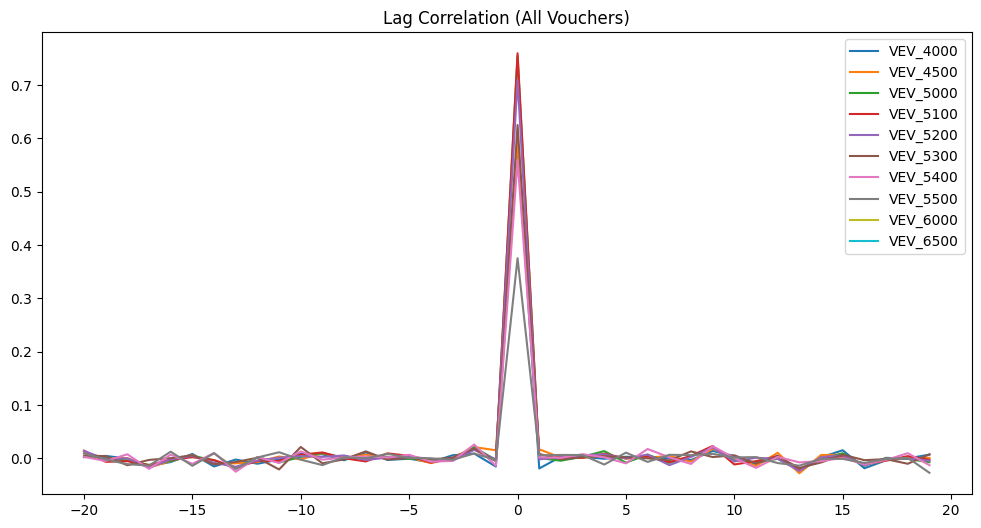

In [25]:
under = prices[prices[price_product_col] == underlying].copy()
under['ret'] = under['mid'].diff()

plt.figure(figsize=(12,6))

for v in vouchers:
    opt = prices[prices[price_product_col] == v].copy()
    opt['ret'] = opt['mid'].diff()

    merged = under[[time_col,'ret']].merge(
        opt[[time_col,'ret']],
        on=time_col,
        suffixes=('_u','_o')
    ).dropna()

    lags = range(-20,20)
    corrs = [merged['ret_u'].shift(l).corr(merged['ret_o']) for l in lags]

    plt.plot(lags, corrs, label=v)

plt.title("Lag Correlation (All Vouchers)")
plt.legend()
plt.show()

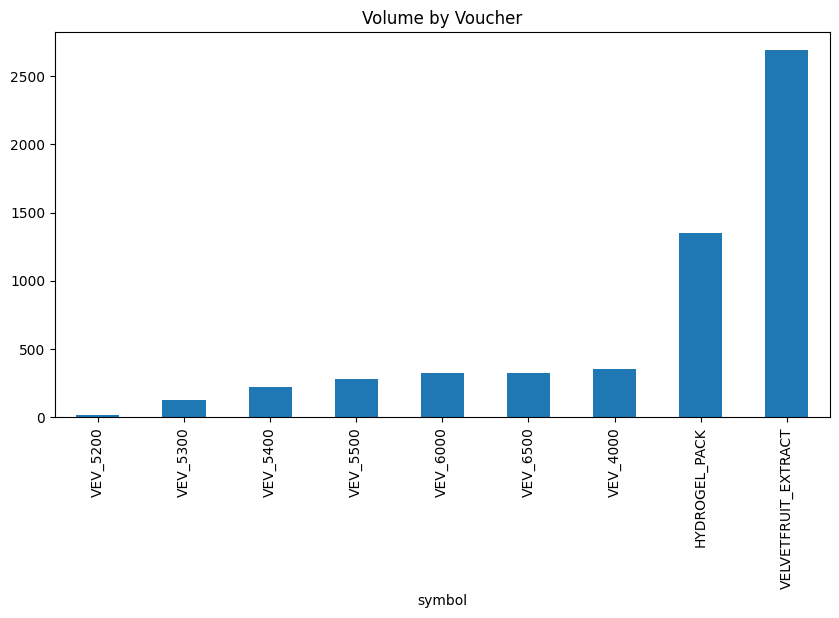

In [26]:
volumes = trades.groupby(trade_product_col)['quantity'].sum()

plt.figure(figsize=(10,5))
volumes.sort_values().plot(kind='bar')
plt.title("Volume by Voucher")
plt.show()

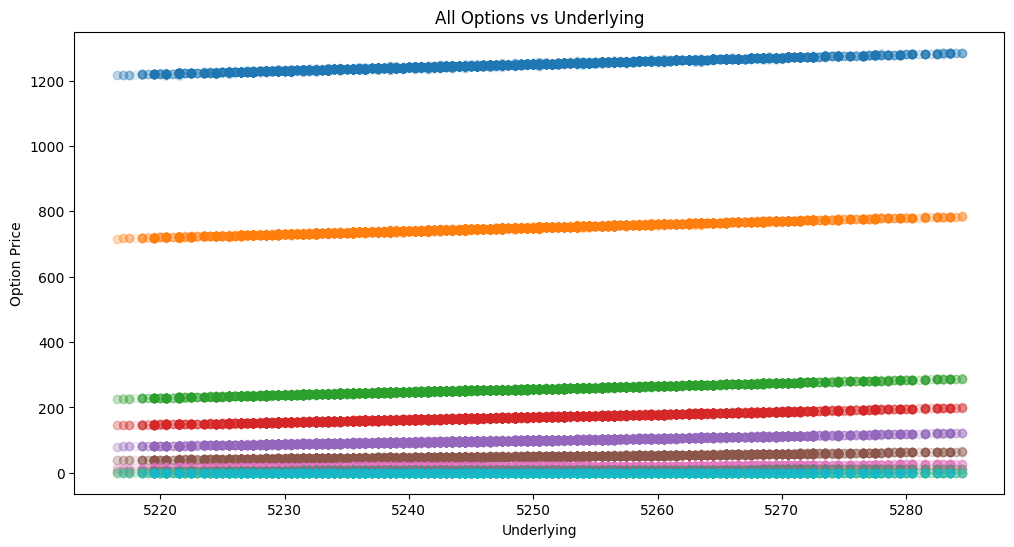

In [28]:
under_df = prices[prices[price_product_col] == underlying][[time_col,'mid']]

plt.figure(figsize=(12,6))

for v in vouchers:
    opt_df = prices[prices[price_product_col] == v][[time_col,'mid']]
    merged = under_df.merge(opt_df, on=time_col, suffixes=('_u','_o'))

    plt.scatter(merged['mid_u'], merged['mid_o'], alpha=0.1)

plt.title("All Options vs Underlying")
plt.xlabel("Underlying")
plt.ylabel("Option Price")
plt.show()

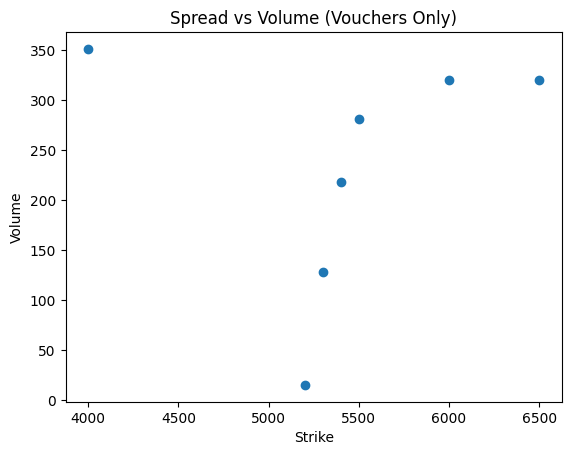

In [30]:
# keep only vouchers
volume = trades[trades['symbol'].str.startswith('VEV_')] \
            .groupby('symbol')['quantity'].sum()

# extract strike safely
volume.index = volume.index.map(lambda x: int(x.split('_')[1]))

# spread already uses strike from prices (correct)
spread = prices.groupby('strike')['spread'].mean()

# align indices (important)
common_strikes = sorted(set(spread.index).intersection(volume.index))

spread = spread.loc[common_strikes]
volume = volume.loc[common_strikes]

plt.figure()
plt.scatter(spread.index, volume.values)
plt.xlabel("Strike")
plt.ylabel("Volume")
plt.title("Spread vs Volume (Vouchers Only)")
plt.show()

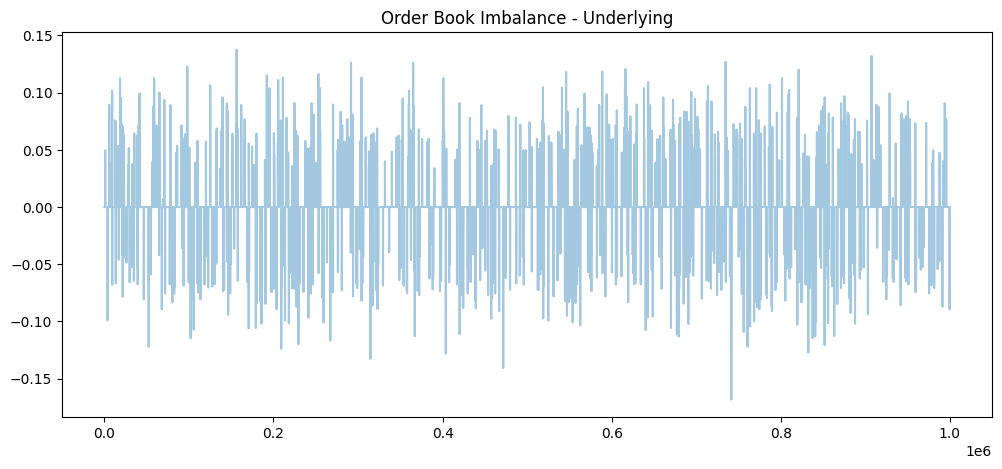

In [31]:
# compute depth
prices['bid_depth'] = prices[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
prices['ask_depth'] = prices[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)

# imbalance
prices['imb'] = (prices['bid_depth'] - prices['ask_depth']) / (
    prices['bid_depth'] + prices['ask_depth'] + 1e-6
)

df = prices[prices[price_product_col] == underlying]

plt.figure(figsize=(12,5))
plt.plot(df[time_col], df['imb'], alpha=0.4)
plt.title("Order Book Imbalance - Underlying")
plt.show()

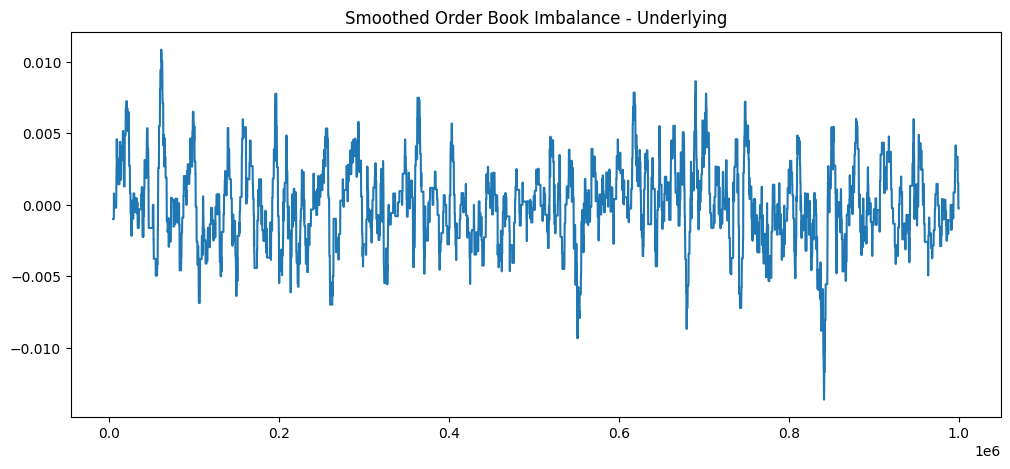

In [32]:
df = prices[prices[price_product_col] == underlying].copy()

df['imb_smooth'] = df['imb'].rolling(50).mean()

plt.figure(figsize=(12,5))
plt.plot(df[time_col], df['imb_smooth'])
plt.title("Smoothed Order Book Imbalance - Underlying")
plt.show()

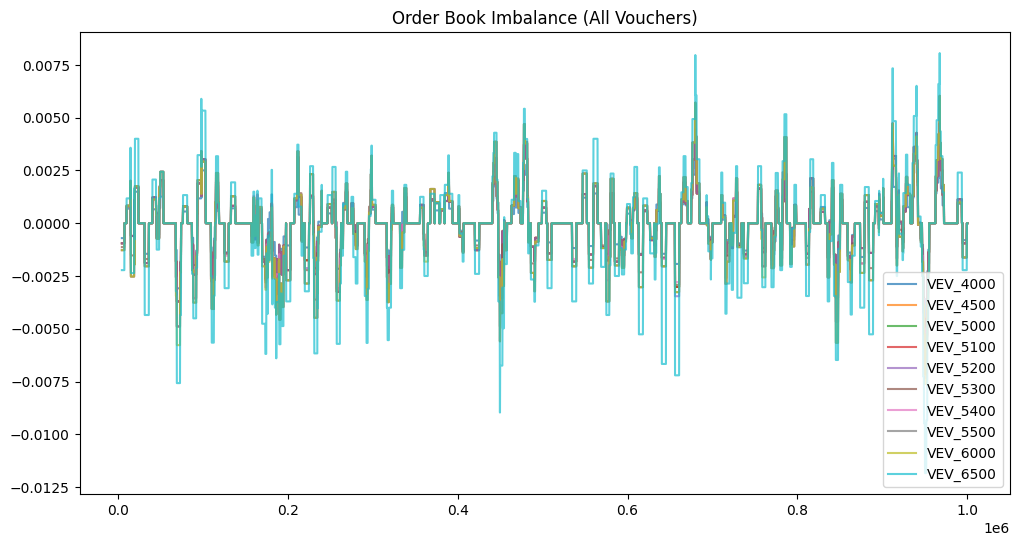

In [33]:
plt.figure(figsize=(12,6))

for v in vouchers:
    df = prices[prices[price_product_col] == v].copy()
    df['imb_smooth'] = df['imb'].rolling(50).mean()
    
    plt.plot(df[time_col], df['imb_smooth'], label=v, alpha=0.7)

plt.title("Order Book Imbalance (All Vouchers)")
plt.legend()
plt.show()

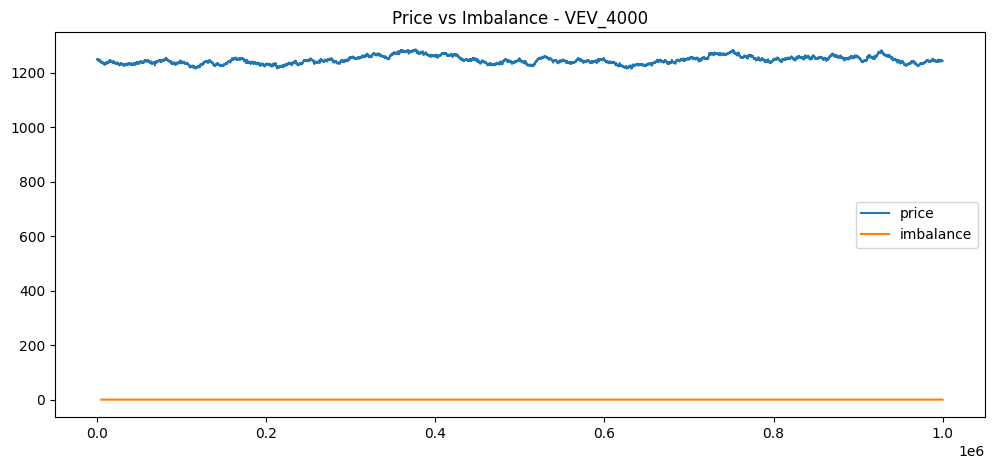

In [34]:
df = prices[prices[price_product_col] == vouchers[0]].copy()

df['imb_smooth'] = df['imb'].rolling(50).mean()

plt.figure(figsize=(12,5))
plt.plot(df[time_col], df['mid'], label='price')
plt.plot(df[time_col], df['imb_smooth'], label='imbalance')
plt.legend()
plt.title(f"Price vs Imbalance - {vouchers[0]}")
plt.show()

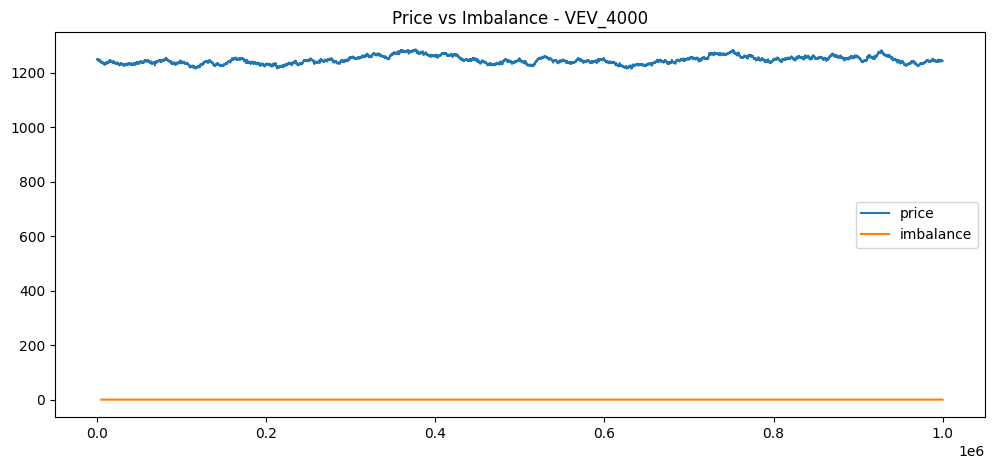

In [35]:
df = prices[prices[price_product_col] == vouchers[0]].copy()

df['imb_smooth'] = df['imb'].rolling(50).mean()

plt.figure(figsize=(12,5))
plt.plot(df[time_col], df['mid'], label='price')
plt.plot(df[time_col], df['imb_smooth'], label='imbalance')
plt.legend()
plt.title(f"Price vs Imbalance - {vouchers[0]}")
plt.show()

In [36]:
df_u = prices[prices[price_product_col] == 'VELVETFRUIT_EXTRACT'].copy()

# mid price
df_u['mid'] = (df_u['bid_price_1'] + df_u['ask_price_1']) / 2

# spread
df_u['spread'] = df_u['ask_price_1'] - df_u['bid_price_1']

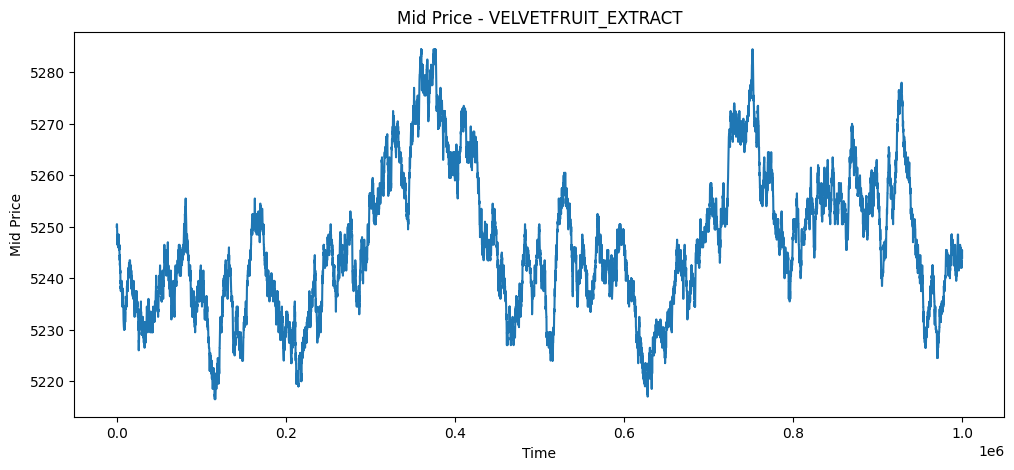

In [37]:
plt.figure(figsize=(12,5))
plt.plot(df_u[time_col], df_u['mid'])
plt.title("Mid Price - VELVETFRUIT_EXTRACT")
plt.xlabel("Time")
plt.ylabel("Mid Price")
plt.show()

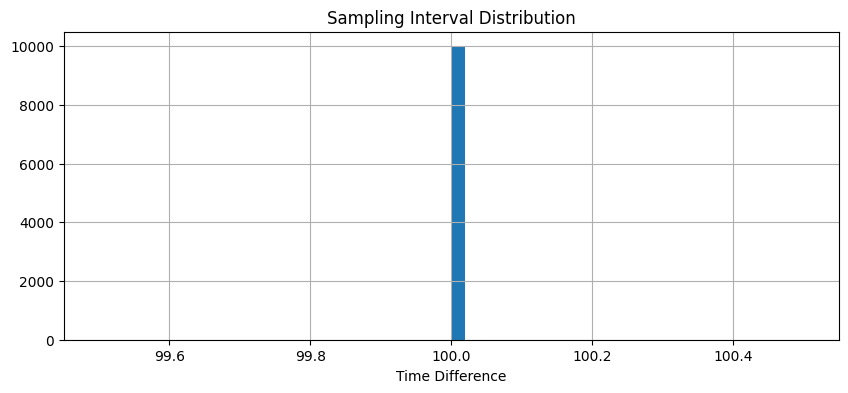

In [39]:
df_u['dt'] = df_u[time_col].diff()

plt.figure(figsize=(10,4))
df_u['dt'].hist(bins=50)
plt.title("Sampling Interval Distribution")
plt.xlabel("Time Difference")
plt.show()

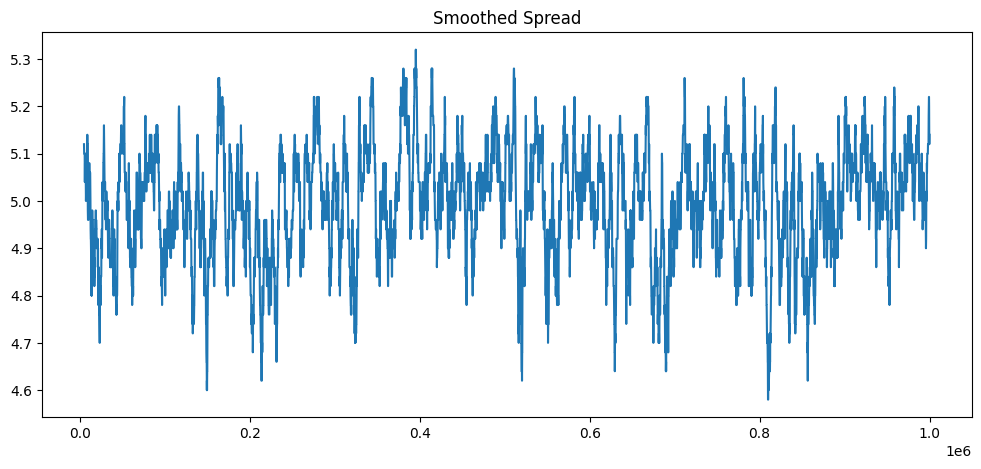

In [41]:
df_u['spread_smooth'] = df_u['spread'].rolling(50).mean()

plt.figure(figsize=(12,5))
plt.plot(df_u[time_col], df_u['spread_smooth'])
plt.title("Smoothed Spread")
plt.show()

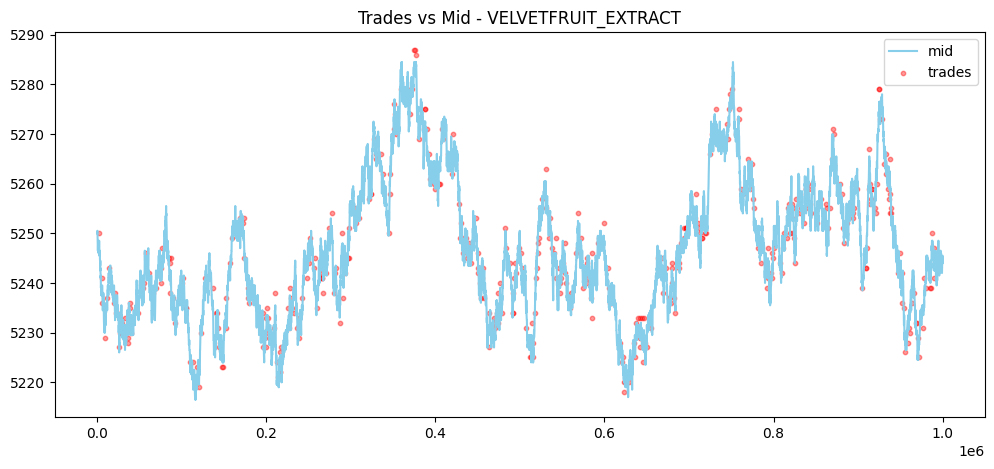

In [48]:
plt.figure(figsize=(12,5))

# mid = line
plt.plot(df_u[time_col], df_u['mid'], color='skyblue', linewidth=1.5, label='mid')

# trades = dots
plt.scatter(tr_u['timestamp'], tr_u['price'],
            color='red', s=10, alpha=0.4, label='trades')

plt.legend()
plt.title("Trades vs Mid - VELVETFRUIT_EXTRACT")
plt.show()

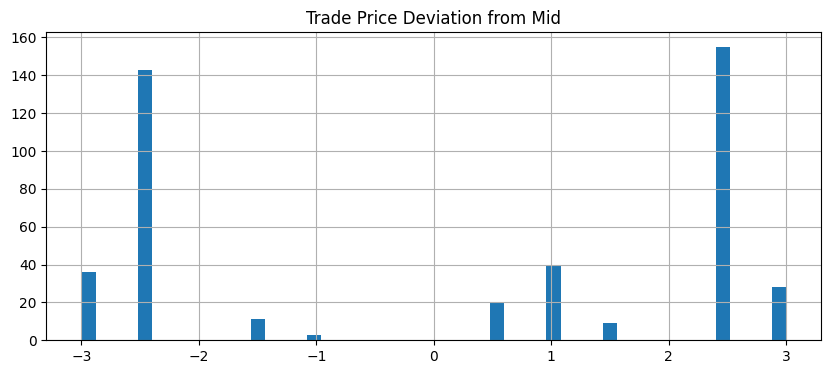

In [43]:
merged = tr_u.merge(
    df_u[[time_col, 'mid']],
    left_on='timestamp',
    right_on=time_col,
    how='left'
)

merged['deviation'] = merged['price'] - merged['mid']

plt.figure(figsize=(10,4))
merged['deviation'].hist(bins=50)
plt.title("Trade Price Deviation from Mid")
plt.show()

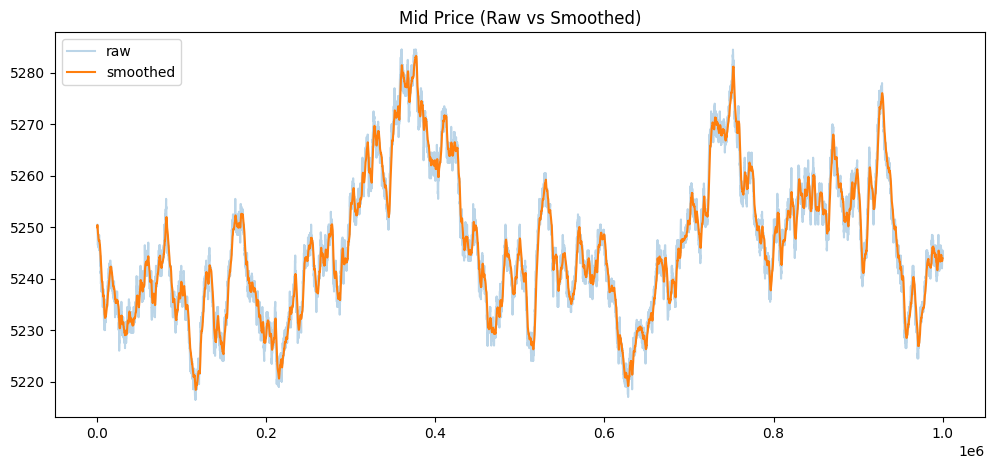

In [44]:
df_u['mid_smooth'] = df_u['mid'].ewm(span=20).mean()

plt.figure(figsize=(12,5))
plt.plot(df_u[time_col], df_u['mid'], alpha=0.3, label='raw')
plt.plot(df_u[time_col], df_u['mid_smooth'], label='smoothed')

plt.legend()
plt.title("Mid Price (Raw vs Smoothed)")
plt.show()